In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential


In [3]:
mnist_df = tf.keras.datasets.mnist

In [4]:
type(mnist_df)

module

In [5]:
(x_train, y_train), (x_test, y_test) = mnist_df.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step


In [6]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [8]:
print("Shape of x_train:", x_train.shape)
print("Shape of y_train:", y_train.shape)
print("____________\n")
print("Shape of x_test:", x_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_train: (60000, 28, 28)
Shape of y_train: (60000,)
____________

Shape of x_test: (10000, 28, 28)
Shape of y_test: (10000,)


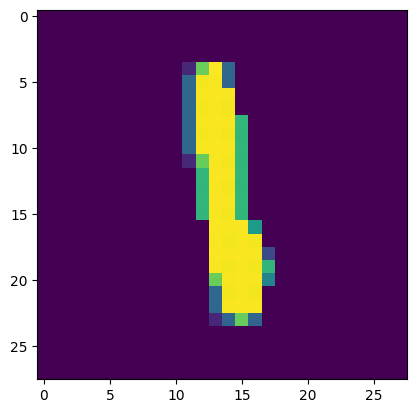

In [14]:
plt.imshow(x_train[200])

In [11]:
y_train[200]

1

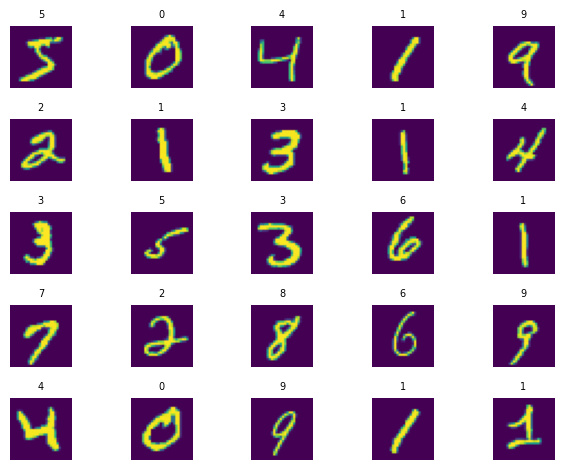

In [13]:
fig, ax = plt.subplots(5,5)
k = 0 
for i in range(5):
    for j in range(5):
        ax[i][j].imshow(x_train[k].reshape(28, 28))
        ax[i][j].set_title(y_train[k], fontsize=7)
        ax[i][j].axis("off")
        k += 1 
plt.tight_layout()
plt.show()



In [15]:
# scaling 
x_train = x_train / 255
x_test = x_test / 255

In [16]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [19]:
## building the model
model = Sequential()

# 1 - input layer - flattening the 28*28 to 784 - input shape 
model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))

# 2 - hidden layer 
model.add(tf.keras.layers.Dense(128, activation="relu"))
model.add(tf.keras.layers.Dense(64, activation="relu"))
model.add(tf.keras.layers.Dense(32, activation="relu"))

# 3 - output layer
model.add(tf.keras.layers.Dense(10, activation="softmax"))

C:\Users\Menna\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
model

<Sequential name=sequential_1, built=True>

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# compiling the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
    )

In [23]:
# fitting the model
model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9159 - loss: 0.2836 - val_accuracy: 0.9583 - val_loss: 0.1418
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9644 - loss: 0.1178 - val_accuracy: 0.9690 - val_loss: 0.1088
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9745 - loss: 0.0842 - val_accuracy: 0.9698 - val_loss: 0.1053
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9797 - loss: 0.0655 - val_accuracy: 0.9718 - val_loss: 0.0954
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9842 - loss: 0.0507 - val_accuracy: 0.9673 - val_loss: 0.1141
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9880 - loss: 0.0397 - val_accuracy: 0.9697 - val_loss: 0.1063
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9880 - loss: 0.0381 - val_accuracy: 0.9742 - val_loss: 0.0980
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9906 - loss: 0.0285 - 

In [24]:
# model evaluation
model.evaluate(x_test, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9745 - loss: 0.1012


[0.10117023438215256, 0.9745000004768372]